# GripFlight：握力与打标数据查看

## 使用目标
选择一次实验，检查握力变化、数据间断，以及任务事件的打标状态。所有读取来自原始导出的 CSV，不连接 Arduino，也不修改实验数据。

从上到下运行所有单元格；之后修改“选择数据”单元格，再重新运行后续单元格即可。图中英文标注避免不同电脑的中文字体缺失。


## 数据与时间含义

- **Voltage (V)** 是握力设备的电压，没有力学校准，不能直接称为 N 或 kg。
- **Task smoothed input** 是任务使用的 0–1 输入；无新数据时可能保持旧值，图中橙色叉号标记已记录的 stale/missing/reader_error。
- 横轴统一使用 `t_host_s`。握力时间是电脑收到完整行的时间，不是 ADC 采样时间。
- ACK/DONE 的横坐标是电脑收到回执的时间，不是脑电采样时刻；模拟回执也会单独统计。
- `device_pulse_ms` 来自同一事件的 Arduino ACK/DONE 计数差，处理一次 micros 回绕；它不是示波器测量。
- 电压曲线不会跨越超过 stale_timeout_s 的采样间隔连线。橙色浅色区域表示采样过期区间。

### 关键假设
查看已结束并导出 CSV 的 session。`status=complete` 只表示任务流程完成，不代表握力和硬件打标全部成功。未找到 CSV 时明确报告缺失，不自动把 SQLite 中未导出的记录当成已查看。


### 1. 导入查看脚本

In [57]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEARCH_ROOTS = [Path.cwd(), *Path.cwd().parents]
VIEWER_DIR = next((p for base in SEARCH_ROOTS for p in [base, base / 'data_viewer']
                   if (p / 'view_data.py').exists()), None)
if VIEWER_DIR is None:
    raise RuntimeError('请从项目文件夹或 data_viewer 打开笔记本，再选择目标电脑的 Python 内核。')
if str(VIEWER_DIR) not in sys.path:
    sys.path.insert(0, str(VIEWER_DIR))
# Load the script beside this notebook, without reusing an old cached module.
import importlib.util
spec = importlib.util.spec_from_file_location('grip_data_viewer_current', VIEWER_DIR / 'view_data.py')
viewer = importlib.util.module_from_spec(spec)
spec.loader.exec_module(viewer)
list_sessions = viewer.list_sessions
load_session = viewer.load_session
quality_summary = viewer.quality_summary
marker_table = viewer.marker_table
plot_session = viewer.plot_session
print('Loaded script:', viewer.__file__)
print('Python:', sys.executable)
print('Viewer:', VIEWER_DIR.resolve())

Loaded script: /Users/heting/grip_psychopy/data_viewer/view_data.py
Python: /Users/heting/miniconda3/envs/eeg/bin/python
Viewer: /Users/heting/grip_psychopy/data_viewer


### 2. 选择数据
`SESSION_NAME=None` 默认按会话目录时间选择最新一次已导出 CSV 的记录，包括模拟记录。每次重新运行读取单元格都会重新选择最新记录。可以指定完整 session 名称来读取历史记录。

In [58]:
DATA_ROOT = 'data'   # 相对于项目根目录，可改成 'test_data'
SESSION_NAME = None # 自动读取最新记录
TRIAL = None         # None=全部；例如 1=第一个 trial
START_S = None       # 例如 5.0；与 t_host_s 相同时间基准
END_S = None         # 例如 20.0

sessions = list_sessions(DATA_ROOT)
display(sessions.head(30))
print('Resolved data folder:', viewer.data_path(DATA_ROOT))
print('Selected session:', SESSION_NAME)

,session,status,simulated,participant,duration_s,csv_available
0,20260909_125240_33ab20a1,complete,False,test,77.042082,True
1,20260909_124632_db765b83,aborted,False,test,35.900962,True
2,20260909_124132_575f1688,aborted,False,test,32.456131,True
3,20260909_123954_788b59a0,aborted,False,test,12.119292,True
4,20260909_122749_e79da856,aborted,False,test,18.273071,True
5,20260909_122704_b66b7ae5,aborted,False,test,15.286148,True
6,20260908_191942_0bf42be5,complete,False,test,79.868566,True
7,20260908_191138_9d28dacb,aborted,False,test,35.106936,True
8,20260908_190452_545061e2,aborted,False,test,16.395500,True
9,20260908_190419_dbbe7033,aborted,False,test,13.008037,True


Resolved data folder: /Users/heting/grip_psychopy/data
Selected session: None


### 3. 读取与数据质量检查

In [59]:
session = load_session(DATA_ROOT, SESSION_NAME)
print('Selected source:', session['path'])
display(quality_summary(session))
print('Runtime warnings:', session['metadata'].get('runtime_warnings', {}))
print('Dropped records:', session['metadata'].get('dropped_records', 0))

Selected source: /Users/heting/grip_psychopy/data/20260909_125240_33ab20a1


,item,value
0,session_status,complete
1,simulated_session,False
2,valid_grip_lines,728
3,invalid_grip_lines,0
4,largest_receive_gap_s,1.565845
5,receive_gaps_over_1.0s,1
6,marker_requests,42
7,hardware_ack_events,42
8,simulated_ack_events,0
9,marker_error_events,0


Runtime warnings: {'grip': 'stale: holding last valid value, or grip_min if none'}
Dropped records: 0


### 4. 原始握力图叠加 event marker bars
上图：原始电压曲线，事件请求时刻直接叠加竖条并标注事件名称和码值；灰色实线表示有 ACK，橙色虚线及 ! 表示失败或没有 ACK，(sim) 表示模拟事件。竖条表示事件时刻，不代表脉冲持续时间。下图保留任务使用的握力。不再单独绘制打标时间线；ACK/DONE 时间仍可在核对表查看。事件较密时设置 START_S / END_S 放大。

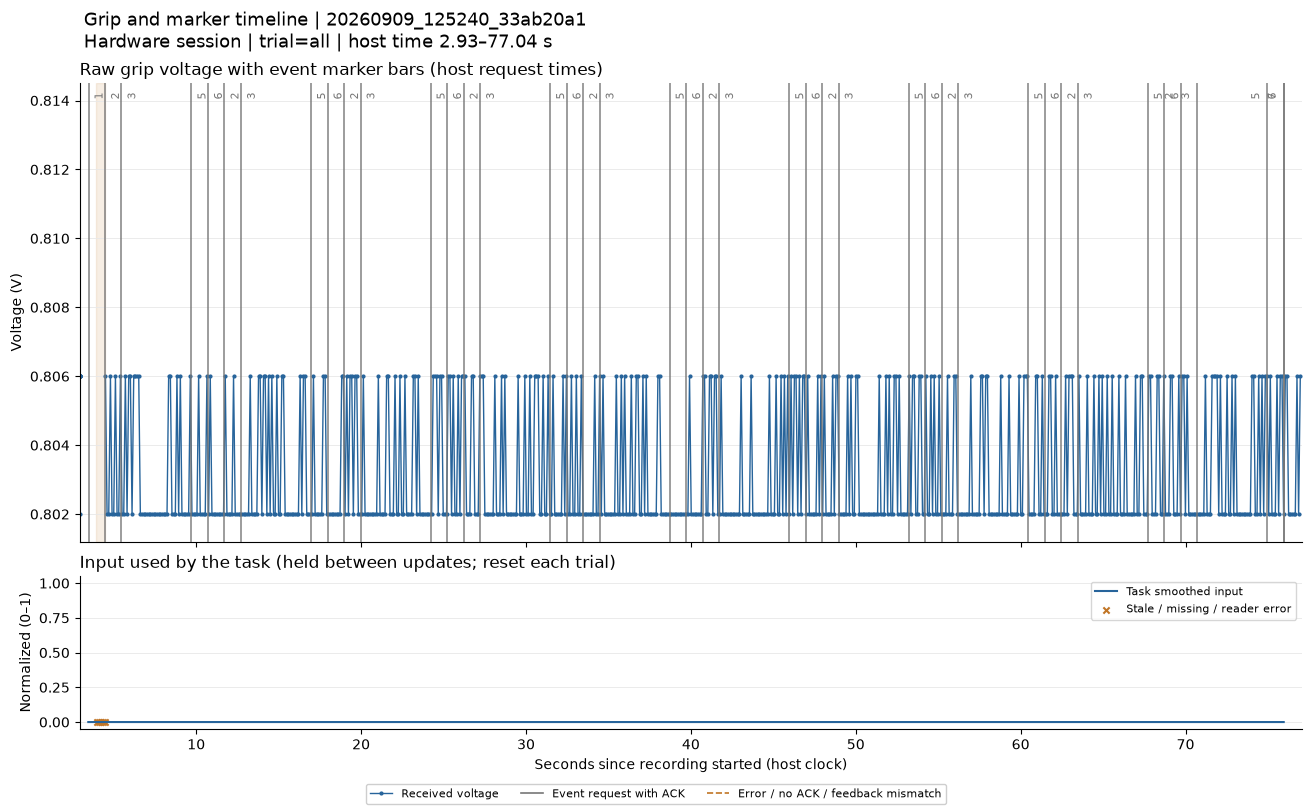

In [60]:
fig = plot_session(session, trial=TRIAL, start=START_S, end=END_S)
plt.show()

### 5. 打标核对表
按 request 的 `id` 与回执的 `event_id` 关联，不按重复的 code 关联。`request_to_ack_ms` 包含队列、串口和回传延迟，不能解释为“EEG 同步误差”。

In [61]:
markers = marker_table(session['events'])
selected_markers = markers if TRIAL is None else markers[markers.trial.eq(TRIAL)]
if START_S is not None:
    selected_markers = selected_markers[selected_markers.request_s >= START_S]
if END_S is not None:
    selected_markers = selected_markers[selected_markers.request_s <= END_S]
display(selected_markers.head(80))
display(selected_markers.groupby(['status', 'simulated'], dropna=False).size().rename('events').reset_index())

,event_id,name,code,trial,mode,feedback_mode,request_s,write_s,ack_s,done_s,...,a0_during_adc,a0_after_adc,a0_during_ok,a0_after_ok,readback_during_code,readback_after_code,readback_during_ok,readback_after_ok,mismatched_pins_during,mismatched_pins_after
0,12,run_start,1,0,output_only,disabled,3.468242,3.468514,3.484634,3.484758,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24,trial_start,2,1,output_only,disabled,4.462053,4.462121,4.479728,4.479843,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,46,feedback_start,3,1,output_only,disabled,5.462001,5.462085,5.479928,5.480069,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,125,collision,5,1,output_only,disabled,9.711941,9.712023,9.726687,9.730470,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,146,trial_end,6,1,output_only,disabled,10.712113,10.712181,10.729928,10.730022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,168,trial_start,2,2,output_only,disabled,11.711912,11.711972,11.729340,11.729429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,189,feedback_start,3,2,output_only,disabled,12.712008,12.712068,12.728851,12.728936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,268,collision,5,2,output_only,disabled,16.962020,16.962085,16.976282,16.980193,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,289,trial_end,6,2,output_only,disabled,17.962045,17.962111,17.979670,17.979765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,311,trial_start,2,3,output_only,disabled,18.963264,18.963318,18.979212,18.982948,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,status,simulated,events
0,done,False,42


### 6. 原始数据与异常行
以下表格保留完整 session 范围，方便追查筛选范围之外的问题。异常行只用于检查，不作为有效握力画入曲线。

In [62]:
grip = session['grip']
display(grip.head(12))
display(grip[grip.kind.eq('grip_invalid')].head(12))
display(session['diagnostics'].tail(15))

,id,kind,t_host_s,trial,block,phase,last_marker_request_id,last_marker_code,payload_json,temperature,voltage,raw,line,error,t
0,1,grip,2.926786,0,1,idle,NaN,NaN,"{""temperature"": 0.0, ""voltage"": 0.802, ""raw"": ...",0.0,0.802,0.802,"0.00,0.802",NaN,2.926786
1,2,grip,2.926850,0,1,idle,NaN,NaN,"{""temperature"": 0.0, ""voltage"": 0.806, ""raw"": ...",0.0,0.806,0.806,"0.00,0.806",NaN,2.926850
2,3,grip,2.926860,0,1,idle,NaN,NaN,"{""temperature"": 0.0, ""voltage"": 0.806, ""raw"": ...",0.0,0.806,0.806,"0.00,0.806",NaN,2.926860
3,4,grip,2.926866,0,1,idle,NaN,NaN,"{""temperature"": 0.0, ""voltage"": 0.806, ""raw"": ...",0.0,0.806,0.806,"0.00,0.806",NaN,2.926866
4,5,grip,2.926871,0,1,idle,NaN,NaN,"{""temperature"": 0.0, ""voltage"": 0.806, ""raw"": ...",0.0,0.806,0.806,"0.00,0.806",NaN,2.926871
5,6,grip,2.927093,0,1,idle,NaN,NaN,"{""temperature"": 0.0, ""voltage"": 0.806, ""raw"": ...",0.0,0.806,0.806,"0.00,0.806",NaN,2.927093
6,7,grip,2.927111,0,1,idle,NaN,NaN,"{""temperature"": 0.0, ""voltage"": 0.806, ""raw"": ...",0.0,0.806,0.806,"0.00,0.806",NaN,2.927111
7,8,grip,2.927118,0,1,idle,NaN,NaN,"{""temperature"": 0.0, ""voltage"": 0.806, ""raw"": ...",0.0,0.806,0.806,"0.00,0.806",NaN,2.927118
8,9,grip,2.927123,0,1,idle,NaN,NaN,"{""temperature"": 0.0, ""voltage"": 0.806, ""raw"": ...",0.0,0.806,0.806,"0.00,0.806",NaN,2.927123
9,27,grip,4.492969,1,1,prepare,24.0,2.0,"{""temperature"": 0.0, ""voltage"": 0.806, ""raw"": ...",0.0,0.806,0.806,"0.00,0.806",NaN,4.492969


,id,kind,t_host_s,trial,block,phase,last_marker_request_id,last_marker_code,payload_json,temperature,voltage,raw,line,error,t


,id,kind,t_host_s,trial,block,phase,last_marker_request_id,last_marker_code,payload_json,error,category,state,age_s,continued
0,10,diagnostic,3.452606,0,1,idle,NaN,NaN,"{""category"": ""grip_status"", ""state"": ""fresh"", ...",NaN,grip_status,fresh,0.525476,True
1,18,diagnostic,3.953687,0,1,pre_run,12.0,1.0,"{""category"": ""grip_status"", ""state"": ""stale"", ...",NaN,grip_status,stale,1.026561,True
2,28,diagnostic,4.578795,1,1,prepare,24.0,2.0,"{""category"": ""grip_status"", ""state"": ""fresh"", ...",NaN,grip_status,fresh,0.085820,True


### 7. 可选：导出当前图与筛选后的打标表
默认不写入文件。设为 True 后写到 data_viewer/exports，不覆盖原始记录。

In [63]:
EXPORT = False
if EXPORT:
    stamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S_%f')
    output = VIEWER_DIR / 'exports' / f'{session["path"].name}_{stamp}'
    output.mkdir(parents=True, exist_ok=False)
    fig.savefig(output / 'grip_markers.png', dpi=180, bbox_inches='tight')
    selected_markers.to_csv(output / 'marker_summary.csv', index=False, encoding='utf-8-sig')
    print('Saved:', output.resolve())

## 阅读结果
先确认所选 session 是否为模拟、是否有有效握力、是否发生长采样间断，再检查每次打标的回执。请求存在但没有 ACK 时，不能判定硬件输出成功；即使有 ACK，也需要脑电软件记录来确认接收链路。重新运行笔记本会按当前参数重新读取数据，缓存的输出只对应上方打印的 Selected source。